/var/folders/n4/p2lmf2l94x3gfqhs72xx2zwr0000gn/T/ipykernel_44175/475806540.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date.strftime('%Y-%m-%d'),
[*********************100%***********************]  1 of 1 completed
19:12:16 - cmdstanpy - INFO - Chain [1] start processing


Fetching data for AAOI from 2024-05-26 to 2026-05-26...
Using 499 trading days of data.
Training Prophet model (this may take a few seconds)...


19:12:17 - cmdstanpy - INFO - Chain [1] done processing



=== RESULTS ===
                                                              0
symbol                                                     AAOI
last_close    Ticker
AAOI    181.49
Name: 2026-05-22 00:00:0...
last_date                                            2026-05-22
forecast_1WK                                           136.8595
forecast_1MO                                           216.2487
forecast_2MO                                           239.0913
forecast_3MO                                           247.7546
forecast_6MO                                           351.7718
return_1D                    Ticker
AAOI    2.65
dtype: float64
return_2D                    Ticker
AAOI    9.82
dtype: float64
return_3D                    Ticker
AAOI    5.93
dtype: float64
return_5D                    Ticker
AAOI   -4.66
dtype: float64
return_7D                   Ticker
AAOI   -18.65
dtype: float64
return_14D                   Ticker
AAOI    4.92
dtype: float64
return_30D             

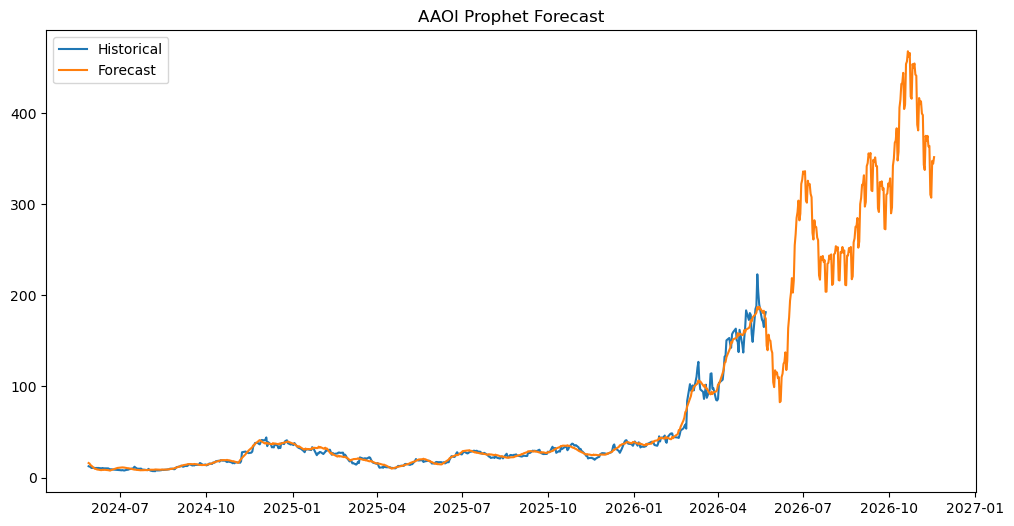

In [7]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
from prophet import Prophet

# ========================= CONFIG =========================
ticker = "AAOI"          # <<< CHANGE THIS TO YOUR TICKER
horizon_choice = '2y'    # Options: 'YTD', '6mo', '1y', '2y'
# ========================================================

end_date = datetime.today()

# Calculate start_date
if horizon_choice == "6mo":
    start_date = end_date - pd.DateOffset(months=6)
elif horizon_choice == "ytd":
    start_date = datetime(end_date.year, 1, 1)
elif horizon_choice == "1y":
    start_date = end_date - pd.DateOffset(years=1)
elif horizon_choice == "2y":
    start_date = end_date - pd.DateOffset(years=2)
else:
    raise ValueError("Invalid time horizon. Choose 'YTD', '6mo', '1y', or '2y'.")

print(f"Fetching data for {ticker} from {start_date.date()} to {end_date.date()}...")

# Fetch historical data
data = yf.download(ticker, start=start_date.strftime('%Y-%m-%d'),
                   end=end_date.strftime('%Y-%m-%d'), interval="1d")

if data.empty:
    raise ValueError(f"No data returned for {ticker}")

# Prepare data for Prophet
df_prophet = data[['Close', 'Volume']].reset_index()
df_prophet.columns = ['ds', 'y', 'volume']
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
df_prophet['y'] = pd.to_numeric(df_prophet['y'], errors='coerce')
df_prophet['volume'] = pd.to_numeric(df_prophet['volume'], errors='coerce')
df_prophet = df_prophet.dropna(subset=['ds', 'y', 'volume'])

print(f"Using {len(df_prophet)} trading days of data.")

# Forecast with Prophet
print("Training Prophet model (this may take a few seconds)...")
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.5,
    seasonality_mode='multiplicative'
)
model.add_regressor('volume')
model.fit(df_prophet)

future = model.make_future_dataframe(periods=180)
future['volume'] = df_prophet['volume'].iloc[-1]  # Use latest volume
forecast = model.predict(future)

# Forecast horizons
forecast_horizons = {'1WK': 7, '1MO': 30, '2MO': 60, '3MO': 90, '6MO': 180}

last_date = df_prophet['ds'].max()
forecasted_prices = {}
for label, days in forecast_horizons.items():
    target_date = last_date + timedelta(days=days)
    closest_idx = (forecast['ds'] - target_date).abs().argmin()
    closest_date = forecast['ds'].iloc[closest_idx]
    price = forecast.loc[forecast['ds'] == closest_date, 'yhat'].iloc[0]
    forecasted_prices[f'forecast_{label}'] = round(price, 4)

# Historical returns
return_periods = [1, 2, 3, 5, 7, 14, 30, 60]
returns = {}
for period in return_periods:
    if len(data) >= period + 1:
        price_now = data['Close'].iloc[-1]
        price_past = data['Close'].iloc[-1 - period]
        ret = (price_now - price_past) / price_past * 100
        returns[f'return_{period}D'] = round(ret, 2)
    else:
        returns[f'return_{period}D'] = None

# Build single-row result DataFrame
result_dict = {
    'symbol': ticker,
    'last_close': round(data['Close'].iloc[-1], 4),
    'last_date': last_date.date()
}
result_dict.update(forecasted_prices)
result_dict.update(returns)

df_result = pd.DataFrame([result_dict])
print("\n=== RESULTS ===")
print(df_result.T)   # Transposed for easier reading

# Optional: show a quick plot (uncomment if you want to see it)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(df_prophet['ds'], df_prophet['y'], label='Historical')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast')
plt.title(f"{ticker} Prophet Forecast")
plt.legend()
plt.show()